In [14]:
!pip install -q -U torchao peft transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 36.3 MB/s eta 0:00:00


In [2]:
import pandas as pd
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer

# 1. Unduh Data Langsung dari Repositori Resmi IndoNLU (SmSA)
url_train = "https://raw.githubusercontent.com/indobenchmark/indoNLU/master/dataset/smsa_doc-sentiment-prosa/train_preprocess.tsv"
url_valid = "https://raw.githubusercontent.com/indobenchmark/indoNLU/master/dataset/smsa_doc-sentiment-prosa/valid_preprocess.tsv"
url_test  = "https://raw.githubusercontent.com/indobenchmark/indoNLU/master/dataset/smsa_doc-sentiment-prosa/test_preprocess_masked_label.tsv"

# Baca data TSV
df_train = pd.read_csv(url_train, sep="\t", header=None, names=["text", "label_raw"])
df_valid = pd.read_csv(url_valid, sep="\t", header=None, names=["text", "label_raw"])
df_test  = pd.read_csv(url_valid, sep="\t", header=None, names=["text", "label_raw"]) # Menggunakan validasi sebagai test set untuk evaluasi label

# Ubah label teks ke angka integer (0: positive, 1: neutral, 2: negative)
mapping_label = {"positive": 0, "neutral": 1, "negative": 2}
df_train["label"] = df_train["label_raw"].map(mapping_label)
df_valid["label"] = df_valid["label_raw"].map(mapping_label)
df_test["label"]  = df_test["label_raw"].map(mapping_label)

# Convert Pandas DataFrame ke Hugging Face DatasetDict
dataset = DatasetDict({
    "train": Dataset.from_pandas(df_train[["text", "label"]]),
    "validation": Dataset.from_pandas(df_valid[["text", "label"]]),
    "test": Dataset.from_pandas(df_test[["text", "label"]])
})

# Label Mapping untuk Model
id2label = {0: "POSITIVE", 1: "NEUTRAL", 2: "NEGATIVE"}
label2id = {"POSITIVE": 0, "NEUTRAL": 1, "NEGATIVE": 2}

# 2. Tokenizer IndoBERT
MODEL_NAME = "indobenchmark/indobert-base-p1"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

tokenized_datasets = dataset.map(tokenize_function, batched=True)
print("\n[SUCCESS] Dataset SmSA IndoNLU berhasil diunduh dan ditokenisasi tanpa error!")

Map:   0%|          | 0/11000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1260 [00:00<?, ? examples/s]

Map:   0%|          | 0/1260 [00:00<?, ? examples/s]


[SUCCESS] Dataset SmSA IndoNLU berhasil diunduh dan ditokenisasi tanpa error!


In [3]:
from transformers import AutoModelForSequenceClassification
from peft import LoraConfig, get_peft_model, TaskType

# 1. Load Model IndoBERT dengan 3 Kelas
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

# 2. Konfigurasi LoRA (PEFT)
peft_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["query", "value"]
)

# Bungkus model dengan LoRA
model = get_peft_model(model, peft_config)

# Cetak jumlah parameter yang dilatih
model.print_trainable_parameters()

[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 297,219 || all params: 124,740,870 || trainable%: 0.2383


--- Memulai Pelatihan Model ---


[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.237404,0.222509,0.924603,0.922592,0.927141,0.924603
2,0.169077,0.186779,0.937302,0.937099,0.937582,0.937302
3,0.112783,0.208102,0.935714,0.935498,0.935899,0.935714



--- Evaluasi pada Test Set ---


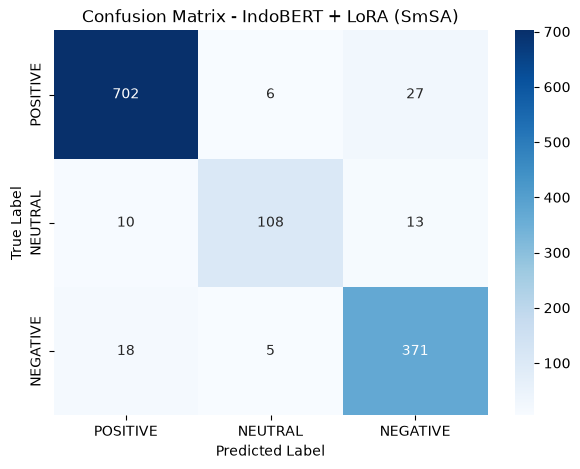

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from transformers import TrainingArguments, Trainer

# 1. Fungsi Evaluasi Metrics (Accuracy, Precision, Recall, F1)
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}

# 2. Pengaturan Hyperparameter
training_args = TrainingArguments(
    output_dir="./indobert_lora_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-3,           # Learning rate ideal untuk LoRA
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=50,
)

# 3. Trainer (menggunakan processing_class yang kompatibel versi terbaru)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

# 4. Jalankan Pelatihan
print("--- Memulai Pelatihan Model ---")
trainer.train()

# 5. Evaluasi pada Test Set & Tampilkan Confusion Matrix
print("\n--- Evaluasi pada Test Set ---")
predictions = trainer.predict(tokenized_datasets["test"])
preds = np.argmax(predictions.predictions, axis=-1)
cm = confusion_matrix(predictions.label_ids, preds)

# Plot Visualisasi Confusion Matrix
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=list(id2label.values()), yticklabels=list(id2label.values()), cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - IndoBERT + LoRA (SmSA)')
plt.show()

In [7]:
import torch

def predict_sentiment(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128, padding=True)
    # Pindahkan input ke device model (GPU/CPU)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        prediction = torch.argmax(logits, dim=-1).item()

    return id2label[prediction]

# Uji coba beberapa contoh kalimat
contoh_kalimat = [
    "Pelayanan di toko ini sangat memuaskan dan respon penjual cepat!",
    "Barangnya biasa saja, tidak terlalu bagus tapi tidak jelek juga.",
    "Sangat kecewa, produk rusak saat sampai dan pengiriman lama sekali."
]

for teks in contoh_kalimat:
    print(f"Teks  : {teks}")
    print(f"Hasil : {predict_sentiment(teks)}\n")

Teks  : Pelayanan di toko ini sangat memuaskan dan respon penjual cepat!
Hasil : POSITIVE

Teks  : Barangnya biasa saja, tidak terlalu bagus tapi tidak jelek juga.
Hasil : NEGATIVE

Teks  : Sangat kecewa, produk rusak saat sampai dan pengiriman lama sekali.
Hasil : NEGATIVE



In [8]:
from google.colab import drive
drive.mount('/content/drive')

# Simpan langsung ke Google Drive
model.save_pretrained("/content/drive/MyDrive/indobert_lora_sentiment_model")
tokenizer.save_pretrained("/content/drive/MyDrive/indobert_lora_sentiment_model")

Mounted at /content/drive


('/content/drive/MyDrive/indobert_lora_sentiment_model/tokenizer_config.json',
 '/content/drive/MyDrive/indobert_lora_sentiment_model/tokenizer.json')